In [14]:
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import accuracy_score
import re
import string
import matplotlib.pyplot as plt

# Klasyfikator Bag of Words

In [15]:
splits = {'train': 'train.parquet', 'validation': 'validation.parquet', 'test': 'test.parquet'}
train_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["train"])
test_df = pd.read_parquet("hf://datasets/cornell-movie-review-data/rotten_tomatoes/" + splits["test"])

In [16]:
test_df[test_df["label"] == 1]

,text,label
0,lovingly photographed in the manner of a golde...,1
1,consistently clever and suspenseful .,1
2,"it's like a "" big chill "" reunion of the baade...",1
3,the story gives ample opportunity for large-sc...,1
4,"red dragon "" never cuts corners .",1
...,...,...
528,both exuberantly romantic and serenely melanch...,1
529,mazel tov to a film about a family's joyous li...,1
530,standing in the shadows of motown is the best ...,1
531,it's nice to see piscopo again after all these...,1


In [17]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().translate(str.maketrans('', '', string.punctuation)))

In [18]:
tokens = [tokenize(t) for t in train_df["text"]]
vocab = sorted(set(word for row in tokens for word in row))
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

In [20]:
def text_to_bow(text):
    vec = torch.zeros(vocab_size)
    for word in tokenize(text):
        if word in word_to_idx:
            vec[word_to_idx[word]] += 1
    return vec

In [23]:
X_train = torch.stack([text_to_bow(t) for t in train_df["text"]])
X_test = torch.stack([text_to_bow(t) for t in test_df["text"]])
y_train = torch.tensor(train_df["label"].values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_df["label"].values, dtype=torch.float32).unsqueeze(1)

In [9]:
model = nn.Sequential(
    nn.Linear(vocab_size, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)

accuracy_history = []

n_epochs = 100
for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        y_test_pred = model(X_test)
        y_pred_labels = (y_test_pred > 0.5).float()
        acc = accuracy_score(y_test, y_pred_labels)
        accuracy_history.append(acc)

    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {loss.item():.4f} | Test accuracy: {acc:.4f}")

Epoch 1/100 | Loss: 0.6932 | Test accuracy: 0.7045
Epoch 2/100 | Loss: 0.6238 | Test accuracy: 0.7280
Epoch 3/100 | Loss: 0.5636 | Test accuracy: 0.7261
Epoch 4/100 | Loss: 0.5135 | Test accuracy: 0.7411
Epoch 5/100 | Loss: 0.4698 | Test accuracy: 0.7392
Epoch 6/100 | Loss: 0.4328 | Test accuracy: 0.7373
Epoch 7/100 | Loss: 0.4007 | Test accuracy: 0.7439
Epoch 8/100 | Loss: 0.3722 | Test accuracy: 0.7458
Epoch 9/100 | Loss: 0.3471 | Test accuracy: 0.7458
Epoch 10/100 | Loss: 0.3250 | Test accuracy: 0.7552
Epoch 11/100 | Loss: 0.3051 | Test accuracy: 0.7552
Epoch 12/100 | Loss: 0.2872 | Test accuracy: 0.7570
Epoch 13/100 | Loss: 0.2710 | Test accuracy: 0.7617
Epoch 14/100 | Loss: 0.2564 | Test accuracy: 0.7608
Epoch 15/100 | Loss: 0.2431 | Test accuracy: 0.7608
Epoch 16/100 | Loss: 0.2309 | Test accuracy: 0.7608
Epoch 17/100 | Loss: 0.2196 | Test accuracy: 0.7589
Epoch 18/100 | Loss: 0.2094 | Test accuracy: 0.7598
Epoch 19/100 | Loss: 0.1999 | Test accuracy: 0.7570
Epoch 20/100 | Loss: 

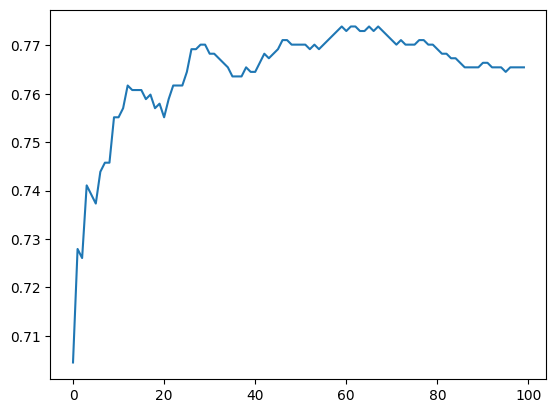

In [10]:
plt.plot(accuracy_history)

tak naiwny klasyfikator działa OK (~80% wykrywa dobrze), a jednak nie umie wykryć bardziej zlozonych markerów "pozytywna/negatywna opinia", więc nie ma sensu uczyć go dużo epoch

# Implementacja algorytmu BPE

In [44]:
from collections import Counter, defaultdict

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().translate(str.maketrans('', '', string.punctuation)))


def prepare_vocab(df):
    vocab = Counter()
    for sentence in df["text"]:
        words = tokenize(sentence)
        for word in words:
            vocab[" ".join(list(word) + ["</w>"])] += 1
    return vocab


def get_pair_frequencies(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs


def apply_new_pair_rule(pair, vocab):
    pattern = re.escape(" ".join(pair))
    replacement = "".join(pair)
    new_vocab = {}
    for word, freq in vocab.items():
        new_word = re.sub(pattern, replacement, word)
        new_vocab[new_word] = freq
    return new_vocab


def train_bpe(vocab, target_bpe_size=10000):
    # initial single-char unigrams
    bpe = set()
    for word in vocab:
        for ch in word.split():
            bpe.add(ch)
    bpe = list(bpe)

    i = 0
    while len(bpe) < target_bpe_size:
        pairs = get_pair_frequencies(vocab)
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        vocab = apply_new_pair_rule(best, vocab)
        bpe.append("".join(best))

        if i % 1000 == 0:
            print(f"Iter {i}: Merged {best} (freq= {pairs.get(best)})")
        i += 1

    return bpe, vocab


vocab = prepare_vocab(train_df)
bpe, final_vocab = train_bpe(vocab, target_bpe_size=10_000)

Iter 0: Merged ('e', '</w>') (freq= 28069)
Iter 1000: Merged ('con', 'flic') (freq= 27)
Iter 2000: Merged ('w', 'rote</w>') (freq= 9)
Iter 3000: Merged ('go', 'als</w>') (freq= 5)
Iter 4000: Merged ('testu', 'd</w>') (freq= 3)
Iter 5000: Merged ('bennet', 'ts</w>') (freq= 2)
Iter 6000: Merged ('in', 'spec') (freq= 2)
Iter 7000: Merged ('undoub', 'ted</w>') (freq= 1)
Iter 8000: Merged ('un', 'spool</w>') (freq= 1)
Iter 9000: Merged ('liber', 'tine</w>') (freq= 1)


In [46]:
def apply_bpe(word: str, bpe: list[str]):
    word = word + "</w>"
    sorted_bpe = sorted(bpe, key=len, reverse=True)
    res = []
    while word:
        for part in sorted_bpe:
            if word.startswith(part):
                res.append(part)
                word = word[len(part):]
                break
    return res


test_words = ["lowest", "newer", "wildest", "undoubted"]
for w in test_words:
    print(w, "->", apply_bpe(w, bpe))

lowest -> ['lo', 'we', 'st', '</w>']
newer -> ['ne', 'we', 'r</w>']
wildest -> ['wild', 'es', 't</w>']
undoubted -> ['undoubted</w>']
